In [1]:
pwd()

'C:\\Users\\CDAC'

In [4]:
%cd C:\Users\CDAC\Desktop\Elaa\Project\HPC_Network_Project\Dataset


C:\Users\CDAC\Desktop\Elaa\Project\HPC_Network_Project\Dataset


In [5]:
pwd()

'C:\\Users\\CDAC\\Desktop\\Elaa\\Project\\HPC_Network_Project\\Dataset'

In [7]:
import pandas as pd
df = pd.read_csv("friday.csv")
df.head()


,Src IP dec,Src Port,Dst IP dec,Dst Port,Protocol,Timestamp,Flow Duration,Total Fwd Packet,Total Bwd packets,Total Length of Fwd Packet,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,ICMP Code,ICMP Type,Total TCP Flow Time,Label,Attempted Category
0,3232238130,56108,3232238083,3268,6,59:50.3,112740690,32,16,6448,...,343,16105402.14,4.988048e+05,16399772,15375229,-1,-1,112740690,BENIGN,-1
1,3232238130,42144,3232238083,389,6,59:50.3,112740560,32,16,6448,...,285,16105427.43,4.987937e+05,16399782,15375263,-1,-1,112740560,BENIGN,-1
2,134610945,0,134219268,0,0,00:31.4,113757377,545,0,0,...,19,12210358.40,6.935824e+06,20757030,5504997,-1,-1,0,BENIGN,-1
3,3232238105,5353,3758096635,5353,17,00:42.9,91997219,388,0,37151,...,16,13197637.00,5.826905e+06,19776791,5817470,-1,-1,0,BENIGN,-1
4,3232238105,123,301796989,123,17,00:42.4,66966070,6,6,288,...,1968172,64974431.00,0.000000e+00,64974431,64974431,-1,-1,0,BENIGN,-1


In [8]:
df['Protocol'].value_counts()


Protocol
6     358430
17    188657
0        295
1        175
Name: count, dtype: int64

In [9]:
def classify_protocol(row):
    proto = row['Protocol']
    dport = row['Dst Port']
    sport = row['Src Port']

    # TCP traffic
    if proto == 6:
        if dport == 80 or sport == 80:
            return "HTTP"
        elif dport == 443 or sport == 443:
            return "HTTPS"
        elif dport == 22 or sport == 22:
            return "SSH"
        elif dport in [25, 110, 143] or sport in [25, 110, 143]:
            return "EMAIL"
        else:
            return "TCP"

    # UDP traffic
    elif proto == 17:
        if dport == 53 or sport == 53:
            return "DNS"
        else:
            return "UDP"

    # ICMP
    elif proto == 1:
        return "ICMP"

    else:
        return "OTHER"


df['App_Protocol'] = df.apply(classify_protocol, axis=1)

df['App_Protocol'].value_counts()


App_Protocol
DNS      180825
TCP      166876
HTTP     127762
HTTPS     62088
UDP        7832
SSH        1225
EMAIL       479
OTHER       295
ICMP        175
Name: count, dtype: int64

In [10]:
df['Traffic_Type'] = "Normal"

# Suspicious: SYN flooding behaviour
df.loc[df['SYN Flag Count'] > 10, 'Traffic_Type'] = "Suspicious"

# Anomalous: extreme packet rate
df.loc[df['Flow Packets/s'] > df['Flow Packets/s'].quantile(0.99),
       'Traffic_Type'] = "Anomalous"

# Anomalous: high variance
df.loc[df['Packet Length Variance'] > df['Packet Length Variance'].quantile(0.99),
       'Traffic_Type'] = "Anomalous"

df['Traffic_Type'].value_counts()


Traffic_Type
Normal        537675
Anomalous       9875
Suspicious         7
Name: count, dtype: int64

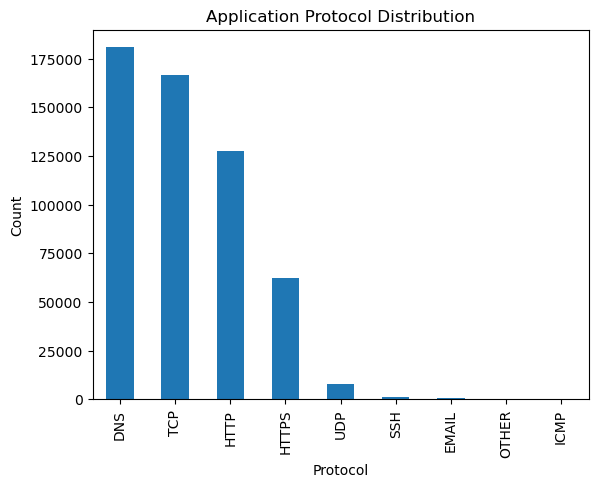

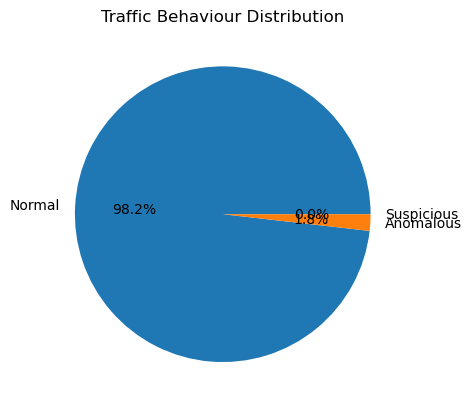

In [11]:
import matplotlib.pyplot as plt

df['App_Protocol'].value_counts().plot(
    kind='bar', title='Application Protocol Distribution')
plt.xlabel("Protocol")
plt.ylabel("Count")
plt.show()

df['Traffic_Type'].value_counts().plot(
    kind='pie', autopct='%1.1f%%', title='Traffic Behaviour Distribution')
plt.ylabel("")
plt.show()


In [12]:
df.to_csv("classified_network_traffic.csv", index=False)
print("Output saved successfully")


Output saved successfully


In [13]:
import time

start_serial = time.time()
_ = df.apply(classify_protocol, axis=1)
end_serial = time.time()

serial_time = end_serial - start_serial
print("Serial Processing Time (seconds):", round(serial_time, 2))


Serial Processing Time (seconds): 13.96


In [ ]:
from multiprocessing import Pool, cpu_count
import numpy as np

def parallel_classification(chunk):
    return chunk.apply(classify_protocol, axis=1)

num_cores = cpu_count()
print("CPU cores available:", num_cores)

# Split dataframe using pandas indexing
chunk_size = len(df) // num_cores
df_chunks = [
    df.iloc[i:i + chunk_size]
    for i in range(0, len(df), chunk_size)
]

start_parallel = time.time()

with Pool(num_cores) as pool:
    result = pool.map(parallel_classification, df_chunks)

df['App_Protocol_Parallel'] = pd.concat(result)

end_parallel = time.time()
parallel_time = end_parallel - start_parallel

print("Parallel Processing Time (seconds):", round(parallel_time, 2))
